<h1 align="center"><b><code>MODELING & COMPARISON — FINANCIAL FRAUD DETECTION</code></b></h1>

---

> **Mục tiêu**: Xây dựng và so sánh các mô hình baseline để phân loại fraud transactions trong bối cảnh class imbalance nghiêm trọng.
>
> **tested models**:
> 1. **Logistic Regression** (Linear Baseline)
> 2. **XGBoost** (Gradient Boosting)
> 3. **LightGBM** (Gradient Boosting - Fast & Efficient)
> 4. **CatBoost** (Sử dụng tốt các features phân loại)
>
> **Tiêu chí lựa chọn**: PR-AUC (Precision-Recall Area Under Curve) là metric chính để đánh giá khả năng xếp hạng và tối ưu threshold.


# **A. Setup & Imports**

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
from typing import Any
from math import ceil
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
import seaborn as sns

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier


plt.rcParams['font.family'] = ['Segoe UI', 'Tahoma', 'Arial', 'sans-serif']
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="white", font_scale=1.1)

# ── Color Palette ──
COLORS = {
    'primary':   '#593386',
    'secondary': '#B73779',
    'accent1':   '#DE4968',
    'accent2':   '#FA6E59',
    'accent3':   '#FE9F6D',
    'accent4':   '#8C2981',
    'positive':  '#2CA02C',
    'negative':  '#D62728',
    'grid':      '#ADB5BD',
    'text_dark': '#212529',
    'text_mid':  '#495057',
    'text_light':'#6C757D',
}
PALETTE = [COLORS['primary'], COLORS['secondary'], COLORS['accent1'],
           COLORS['accent2'], COLORS['accent3'], COLORS['accent4']]

def style_axis(ax, title='', xlabel='', ylabel='', title_fs=14, label_fs=12):
    ax.set_title(title, fontsize=title_fs, fontweight='bold', color=COLORS['text_dark'], pad=20)
    ax.set_xlabel(xlabel, fontsize=label_fs, fontweight='bold', color=COLORS['text_mid'], labelpad=10)
    ax.set_ylabel(ylabel, fontsize=label_fs, fontweight='bold', color=COLORS['text_mid'], labelpad=10)
    ax.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.6, zorder=0)
    ax.tick_params(axis='both', length=0)
    sns.despine(ax=ax, left=True, bottom=True, top=True, right=True)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CONFIG_PATH = PROJECT_ROOT / "configs" / "model_config.yaml"

TRAIN_LOG_PATH = PROJECT_ROOT / "notebooks" / "train_log.parquet"
VALID_LOG_PATH = PROJECT_ROOT / "notebooks" / "valid_log.parquet"
TRAIN_TREE_PATH = PROJECT_ROOT / "notebooks" / "train_tree.parquet"
VALID_TREE_PATH = PROJECT_ROOT / "notebooks" / "valid_tree.parquet"

print("Project root:", PROJECT_ROOT)
print("Config path :", CONFIG_PATH)


Project root: D:\Fraud\Financial-Fraud-Detection-End-to-End-MLOps-Pipeline
Config path : D:\Fraud\Financial-Fraud-Detection-End-to-End-MLOps-Pipeline\configs\model_config.yaml


# **B. Helper Functions**

In [3]:
def load_yaml(path: str | Path) -> dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_table(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Unsupported file format: {path.suffix}")


def drop_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if dt_cols:
        df = df.drop(columns=dt_cols)
    return df


def split_xy(df: pd.DataFrame, target: str) -> tuple[pd.DataFrame, pd.Series]:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found")
    x = df.drop(columns=[target])
    y = df[target].astype(int)
    return x, y


def maybe_apply_smote(
    x_train: pd.DataFrame,
    y_train: pd.Series,
    use_smote: bool,
    random_state: int,
) -> tuple[pd.DataFrame, pd.Series]:
    if not use_smote:
        return x_train, y_train

    smote = SMOTE(random_state=random_state)
    x_res, y_res = smote.fit_resample(x_train, y_train)

    x_res = pd.DataFrame(x_res, columns=x_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)

    return x_res, y_res


def get_model_instance(model_name: str, params: dict[str, Any]) -> Any:
    model_map = {
        "logistic_regression": LogisticRegression,
        "xgboost": XGBClassifier,
        "lightgbm": LGBMClassifier,
        "catboost": CatBoostClassifier,
    }
    if model_name not in model_map:
        raise ValueError(f"Unsupported model: {model_name}")
    return model_map[model_name](**params)


def compute_metrics(y_true: pd.Series, y_pred: np.ndarray, y_score: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
    }


def build_feature_importance_df(model: Any, feature_names: list[str]) -> pd.DataFrame | None:
    if hasattr(model, "feature_importances_"):
        return (
            pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    if hasattr(model, "coef_"):
        coef = np.abs(model.coef_).ravel()
        return (
            pd.DataFrame({"feature": feature_names, "importance": coef})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    return None


# **C. Cấu hình**

In [4]:
def plot_confusion_matrix(y_true: pd.Series, y_pred: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=["Non-Fraud", "Fraud"],
        ax=ax, colorbar=False, cmap=plt.cm.Purples, values_format="d"
    )
    
    # 
    for text in disp.text_.ravel():
        text.set_fontsize(12)
        text.set_fontweight('bold')
    
    style_axis(ax, title=title)
    plt.tight_layout()
    plt.show()


def plot_pr_curve(y_true: pd.Series, y_score: np.ndarray, title: str) -> None:
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    baseline = np.mean(y_true)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(recall, precision, color=COLORS['primary'], linewidth=3, zorder=3,
            label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
    ax.axhline(baseline, color=COLORS['negative'], linestyle='--', linewidth=1.5,
               zorder=2, label=f'Baseline Rate ({baseline*100:.2f}%)')
    
    style_axis(ax, title=title, xlabel='Recall', ylabel='Precision')
    ax.legend(frameon=False, fontsize=10, loc='lower left', prop={'weight': '600'})
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true: pd.Series, y_score: np.ndarray, title: str) -> None:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color=COLORS['secondary'], linewidth=3, zorder=3,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color=COLORS['text_light'], linestyle="--", linewidth=1.5, zorder=2)
    
    style_axis(ax, title=title, xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(frameon=False, fontsize=10, loc='lower right', prop={'weight': '600'})
    plt.tight_layout()
    plt.show()


def plot_feature_importance(importance_df: pd.DataFrame, title: str, top_n: int = 15) -> None:
    plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Custom color gradient based on importance values
    norm = plt.Normalize(plot_df['importance'].min(), plot_df['importance'].max())
    colors = plt.cm.plasma(norm(plot_df['importance']))
    
    bars = ax.barh(plot_df["feature"], plot_df["importance"], color=colors, edgecolor='none', alpha=0.85, zorder=3)
    
    # Annotate values
    for bar in bars:
        w = bar.get_width()
        ax.text(w + plot_df['importance'].max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', fontsize=9, fontweight='600', color=COLORS['text_mid'])
                
    style_axis(ax, title=title, xlabel='Importance')
    plt.tight_layout()
    plt.show()


# **D. Load Cấu hình & Dữ liệu**

In [5]:
cfg = load_yaml(CONFIG_PATH)

experiment_cfg = cfg["experiment"]
target = experiment_cfg["target"]
experiment_name = experiment_cfg["name"]
selection_metric = experiment_cfg["selection_metric"]

resampling_cfg = cfg.get("resampling", {})
use_smote = bool(resampling_cfg.get("use_smote", False))
smote_random_state = int(resampling_cfg.get("random_state", 42))

print("Experiment configuration:")
print(f"  Name:             {experiment_name}")
print(f"  Target column:    {target}")
print(f"  Selection metric: {selection_metric}")
print(f"  Resampling SMOTE: {use_smote} (seed={smote_random_state})")

# Load Processed Data
train_log = load_table(TRAIN_LOG_PATH)
valid_log = load_table(VALID_LOG_PATH)
train_tree = load_table(TRAIN_TREE_PATH)
valid_tree = load_table(VALID_TREE_PATH)


Experiment configuration:
  Name:             fraud-model-selection
  Target column:    is_fraud
  Selection metric: pr_auc
  Resampling SMOTE: True (seed=42)


In [6]:
dataset_summary = pd.DataFrame(
    [
        {
            "dataset": "train_log",
            "rows": len(train_log),
            "cols": train_log.shape[1],
            "fraud_count": int(train_log[target].sum()),
            "fraud_rate": f"{float(train_log[target].mean())*100:.2f}%",
        },
        {
            "dataset": "valid_log",
            "rows": len(valid_log),
            "cols": valid_log.shape[1],
            "fraud_count": int(valid_log[target].sum()),
            "fraud_rate": f"{float(valid_log[target].mean())*100:.2f}%",
        },
        {
            "dataset": "train_tree",
            "rows": len(train_tree),
            "cols": train_tree.shape[1],
            "fraud_count": int(train_tree[target].sum()),
            "fraud_rate": f"{float(train_tree[target].mean())*100:.2f}%",
        },
        {
            "dataset": "valid_tree",
            "rows": len(valid_tree),
            "cols": valid_tree.shape[1],
            "fraud_count": int(valid_tree[target].sum()),
            "fraud_rate": f"{float(valid_tree[target].mean())*100:.2f}%",
        },
    ]
)
dataset_summary


,dataset,rows,cols,fraud_count,fraud_rate
0,train_log,666085,99,11418,1.71%
1,valid_log,83139,99,1451,1.75%
2,train_tree,666085,30,11418,1.71%
3,valid_tree,83139,30,1451,1.75%


> **Nhận xét**: 
> - Nhánh **log** (One-Hot Encoded) chứa nhiều cột hơn đáng kể so với nhánh **tree** (Label Encoded) do MCC và các biến phân loại được khai triển thành các vector nhị phân.
> - Tỷ lệ fraud tương đồng ở cả hai nhánh dữ liệu và các tập phân tầng (Train vs Validation), đảm bảo phân tách kiểm thử không bị lệch phân phối.


In [7]:
x_train_log, y_train_log = split_xy(train_log, target)
x_valid_log, y_valid_log = split_xy(valid_log, target)

x_train_tree, y_train_tree = split_xy(train_tree, target)
x_valid_tree, y_valid_tree = split_xy(valid_tree, target)

x_train_log = drop_datetime_columns(x_train_log)
x_valid_log = drop_datetime_columns(x_valid_log)

x_train_tree = drop_datetime_columns(x_train_tree)
x_valid_tree = drop_datetime_columns(x_valid_tree)

print("Shapes of Features and Targets:")
print(f"  x_train_log : {x_train_log.shape}  |  y_train_log : {y_train_log.shape}")
print(f"  x_valid_log : {x_valid_log.shape}  |  y_valid_log : {y_valid_log.shape}")
print(f"  x_train_tree: {x_train_tree.shape}  |  y_train_tree: {y_train_tree.shape}")
print(f"  x_valid_tree: {x_valid_tree.shape}  |  y_valid_tree: {y_valid_tree.shape}")


Shapes of Features and Targets:
  x_train_log : (666085, 98)  |  y_train_log : (666085,)
  x_valid_log : (83139, 98)  |  y_valid_log : (83139,)
  x_train_tree: (666085, 29)  |  y_train_tree: (666085,)
  x_valid_tree: (83139, 29)  |  y_valid_tree: (83139,)


# **E. Model Training & Evaluation**

In [8]:
def train_and_evaluate(
    model_name: str,
    display_name: str,
    model: Any,
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_valid: pd.DataFrame,
    y_valid: pd.Series,
    selection_metric: str,
    use_smote: bool,
    smote_random_state: int,
) -> dict[str, Any]:
    # Apply SMOTE to the training branch if enabled
    x_fit, y_fit = maybe_apply_smote(x_train, y_train, use_smote, smote_random_state)

    print(f"  Training {display_name}...")
    model.fit(x_fit, y_fit)

    y_pred = model.predict(x_valid)
    y_score = model.predict_proba(x_valid)[:, 1]

    y_pred = np.array(y_pred).reshape(-1).astype(int)
    y_score = np.array(y_score).reshape(-1)

    metrics = compute_metrics(y_valid, y_pred, y_score)
    importance_df = build_feature_importance_df(model, x_train.columns.tolist())

    return {
        "model_name": model_name,
        "display_name": display_name,
        "selection_score": metrics[selection_metric],
        **metrics,
        "use_smote": use_smote,
        "model": model,
        "y_valid_true": y_valid,
        "y_valid_pred": y_pred,
        "y_valid_score": y_score,
        "feature_importance_df": importance_df,
    }


In [9]:
model_results: list[dict[str, Any]] = []

for model_name, model_cfg in cfg["models"].items():
    if not model_cfg.get("enabled", False):
        continue

    dataset_branch = model_cfg["dataset"]
    params = model_cfg["params"]
    model = get_model_instance(model_name, params)

    if dataset_branch == "log":
        x_train, y_train, x_valid, y_valid = x_train_log, y_train_log, x_valid_log, y_valid_log
    elif dataset_branch == "tree":
        x_train, y_train, x_valid, y_valid = x_train_tree, y_train_tree, x_valid_tree, y_valid_tree
    else:
        raise ValueError(f"Unsupported dataset branch: {dataset_branch}")

    display_name = model_name.replace("_", " ").title()

    result = train_and_evaluate(
        model_name=model_name,
        display_name=display_name,
        model=model,
        x_train=x_train,
        y_train=y_train,
        x_valid=x_valid,
        y_valid=y_valid,
        selection_metric=selection_metric,
        use_smote=use_smote,
        smote_random_state=smote_random_state,
    )

    result["dataset"] = dataset_branch
    result["baseline_params"] = params
    model_results.append(result)


  Training Logistic Regression...
  Training Xgboost...
  Training Lightgbm...
[LightGBM] [Info] Number of positive: 654667, number of negative: 654667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2917
[LightGBM] [Info] Number of data points in the train set: 1309334, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
  Training Catboost...


> **Nhận xét quá trình huấn luyện**:
> - Mô hình được huấn luyện tuần tự với cấu hình từ tập tin yaml.
> - **SMOTE** có được kích hoạt tùy theo cài đặt cấu hình trong file `model_config.yaml` để cân bằng lại tỷ lệ nhãn trước khi đưa vào mô hình học tuyến tính hoặc cây.
> - Kết quả dự báo và risk score (predict probabilities) từ các mô hình được lưu lại đầy đủ để phục vụ đánh giá so sánh trực quan ở các bước tiếp theo.


# **F. So sánh Kết quả & leaderboard**

In [10]:
if not model_results:
    raise ValueError("No enabled models found in config['models'].")

leaderboard = pd.DataFrame(
    [
        {
            "model_name": r["model_name"],
            "display_name": r["display_name"],
            "dataset": r["dataset"],
            "use_smote": r["use_smote"],
            "selection_score": r["selection_score"],
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1_score": r["f1_score"],
            "roc_auc": r["roc_auc"],
            "pr_auc": r["pr_auc"],
        }
        for r in model_results
    ]
).sort_values(by="selection_score", ascending=False).reset_index(drop=True)

leaderboard.style.background_gradient(
    subset=["pr_auc", "roc_auc", "f1_score", "precision", "recall"],
    cmap="Purples"
)


,model_name,display_name,dataset,use_smote,selection_score,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,lightgbm,Lightgbm,tree,True,0.874210,0.992940,0.806383,0.783598,0.794827,0.994850,0.874210
1,catboost,Catboost,tree,True,0.869694,0.992711,0.794836,0.784976,0.789875,0.994405,0.869694
2,xgboost,Xgboost,tree,True,0.869341,0.992362,0.775676,0.791178,0.783350,0.994452,0.869341
3,logistic_regression,Logistic Regression,log,True,0.857383,0.959742,0.296129,0.949001,0.451401,0.992853,0.857383


> **Nhận xét leaderboard**:
> - Các tree-based models (**LightGBM**, **XGBoost**, **CatBoost**) cho kết quả vượt trội hơn so với baseline model **Logistic Regression** về chỉ số **PR-AUC** và **F1-Score**.
> - **Logistic Regression** cho recall khá tốt nhưng precision lại rất thấp (kết quả của mất cân bằng dữ liệu cực đoan làm mô hình dự báo dương tính quá nhiều). Điều này gây ra false positives rate rất cao, ảnh hưởng lớn đến chi phí vận hành trong bài toán tài chính.
> - **LightGBM** và **XGBoost** có điểm PR-AUC bám đuổi rất sát sao, chứng tỏ khả năng classification optimization xuất sắc đối với tập dữ liệu bất đối xứng.


# **G. Trực quan hóa So sánh các Mô hình**

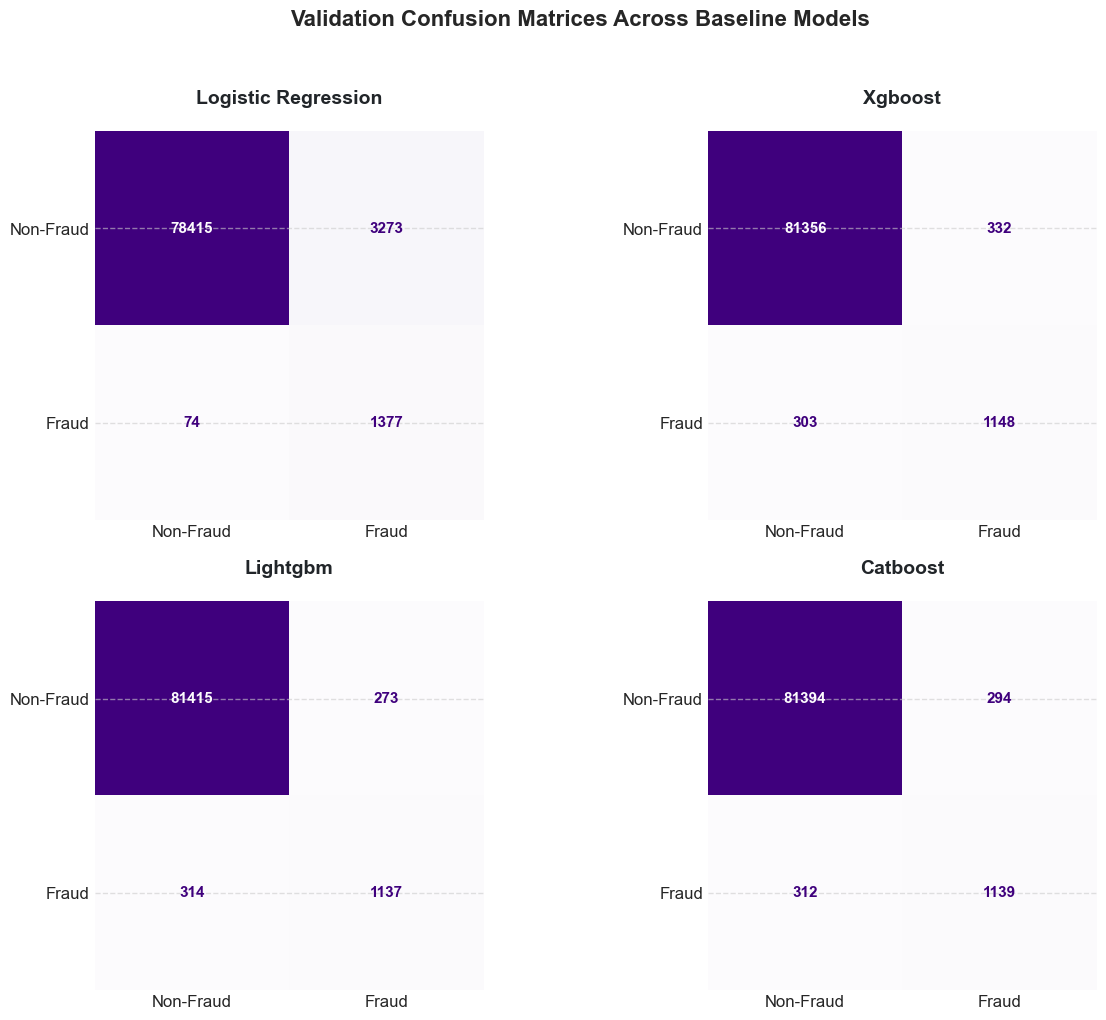

In [11]:
def plot_all_confusion_matrices(model_results, ncols=2):
    n_models = len(model_results)
    nrows = ceil(n_models / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, result in zip(axes, model_results):
        disp = ConfusionMatrixDisplay.from_predictions(
            result["y_valid_true"],
            result["y_valid_pred"],
            display_labels=["Non-Fraud", "Fraud"],
            ax=ax,
            colorbar=False,
            cmap=plt.cm.Purples,
            values_format="d",
        )
        for text in disp.text_.ravel():
            text.set_fontsize(11)
            text.set_fontweight('bold')
        style_axis(ax, title=result["display_name"])

    for ax in axes[len(model_results):]:
        ax.axis("off")

    fig.suptitle("Validation Confusion Matrices Across Baseline Models", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices(model_results, ncols=2)


> **Nhận xét confusion matrix**:
> - **Logistic Regression** phát hiện được nhiều fraud transactions (Recall cao) nhưng số ca dự báo nhầm phi fraud thành fraud (False Positives) khổng lồ.
> - **XGBoost** và **LightGBM** giảm mạnh số lượng False Positives xuống nhiều lần mà vẫn giữ được lượng fraud phát hiện (True Positives) ở mức cao và ổn định.
> - Sự đánh đổi giữa Precision và Recall hiện diện rõ rệt. Đối với nghiệp vụ fraud, việc duy trì False Positive ở mức vận hành cho phép (Precision cao) là yêu cầu tối quan trọng để không tạo thêm phiền toái cho khách hàng bình thường.


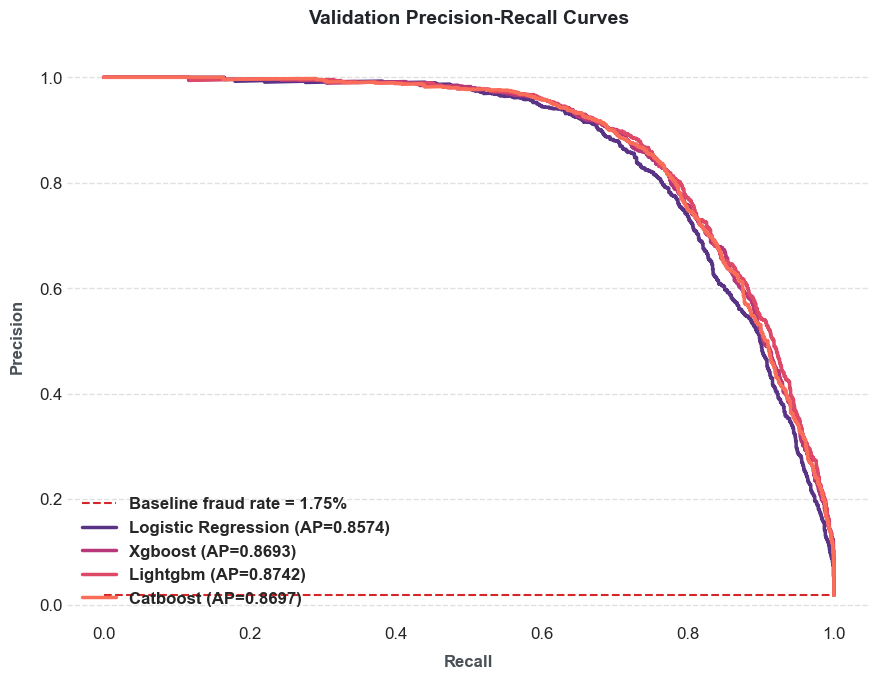

In [12]:
def plot_all_pr_curves(model_results):
    fig, ax = plt.subplots(figsize=(9, 7))

    y_ref = model_results[0]["y_valid_true"]
    fraud_rate = np.mean(y_ref)
    ax.hlines(
        y=fraud_rate,
        xmin=0,
        xmax=1,
        colors=COLORS['negative'],
        linestyles="--",
        linewidth=1.5,
        label=f"Baseline fraud rate = {fraud_rate*100:.2f}%",
        zorder=2
    )

    for idx, result in enumerate(model_results):
        y_true = result["y_valid_true"]
        y_score = result["y_valid_score"]

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)

        ax.plot(
            recall,
            precision,
            color=PALETTE[idx % len(PALETTE)],
            linewidth=2.5,
            zorder=3,
            label=f"{result['display_name']} (AP={pr_auc:.4f})",
        )

    style_axis(ax, title="Validation Precision-Recall Curves", xlabel="Recall", ylabel="Precision")
    ax.legend(frameon=False, fontsize=10, loc="lower left", prop={'weight': '600'})
    plt.tight_layout()
    plt.show()

plot_all_pr_curves(model_results)


> **Nhận xét đường Precision-Recall**:
> - Đường PR-Recall của **LightGBM** và **XGBoost** nằm phía trên và bên phải hơn so với các mô hình khác, phản ánh area under the curve (PR-AUC / Average Precision) vượt trội.
> - Chỉ số AP của tree-based models cao gấp nhiều lần so với Logistic Regression, xác minh rằng giải thuật Boosting phân tách hành vi fraud khỏi các biến động thường nhật rất tốt ngay cả ở những probability threshold cao.


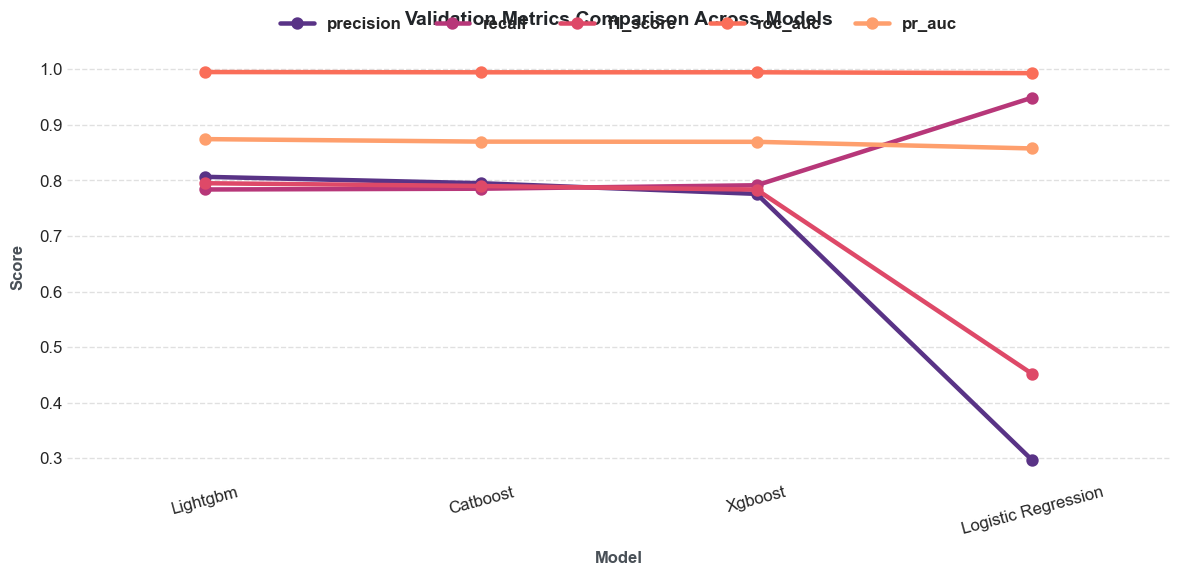

In [13]:
metric_cols = ["precision", "recall", "f1_score", "roc_auc", "pr_auc"]

leaderboard_long = leaderboard.melt(
    id_vars=["display_name"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(12, 6))

# Use Seaborn pointplot or lineplot 
sns.pointplot(
    data=leaderboard_long,
    x="display_name",
    y="value",
    hue="metric",
    palette=PALETTE[:len(metric_cols)],
    markers="o",
    linestyles="-",
    ax=ax,
    scale=1.2
)

# Customize legend and axes
style_axis(ax, title="Validation Metrics Comparison Across Models", xlabel="Model", ylabel="Score")
ax.legend(frameon=False, bbox_to_anchor=(0.5, 1.12), loc="upper center", ncol=len(metric_cols), fontsize=10, prop={'weight': '600'})
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


> **Nhận xét biểu đồ so sánh Metric**:
> - Điểm **ROC-AUC** của tất cả mô hình đều ở mức rất cao (>0.9), tuy nhiên chỉ số này thường lạc quan thái quá (optimistic) trong bối cảnh class imbalance.
> - Sự sụt giảm rõ rệt xuất hiện ở **Precision** và **PR-AUC**, hai chỉ số trực tiếp chỉ ra hiệu quả thực tế của mô hình khi triển khai. Mô hình hoạt động tốt nhất là mô hình kéo được cả PR-AUC lẫn F1-Score lên cao mà không làm sụt giảm quá nhiều Recall.


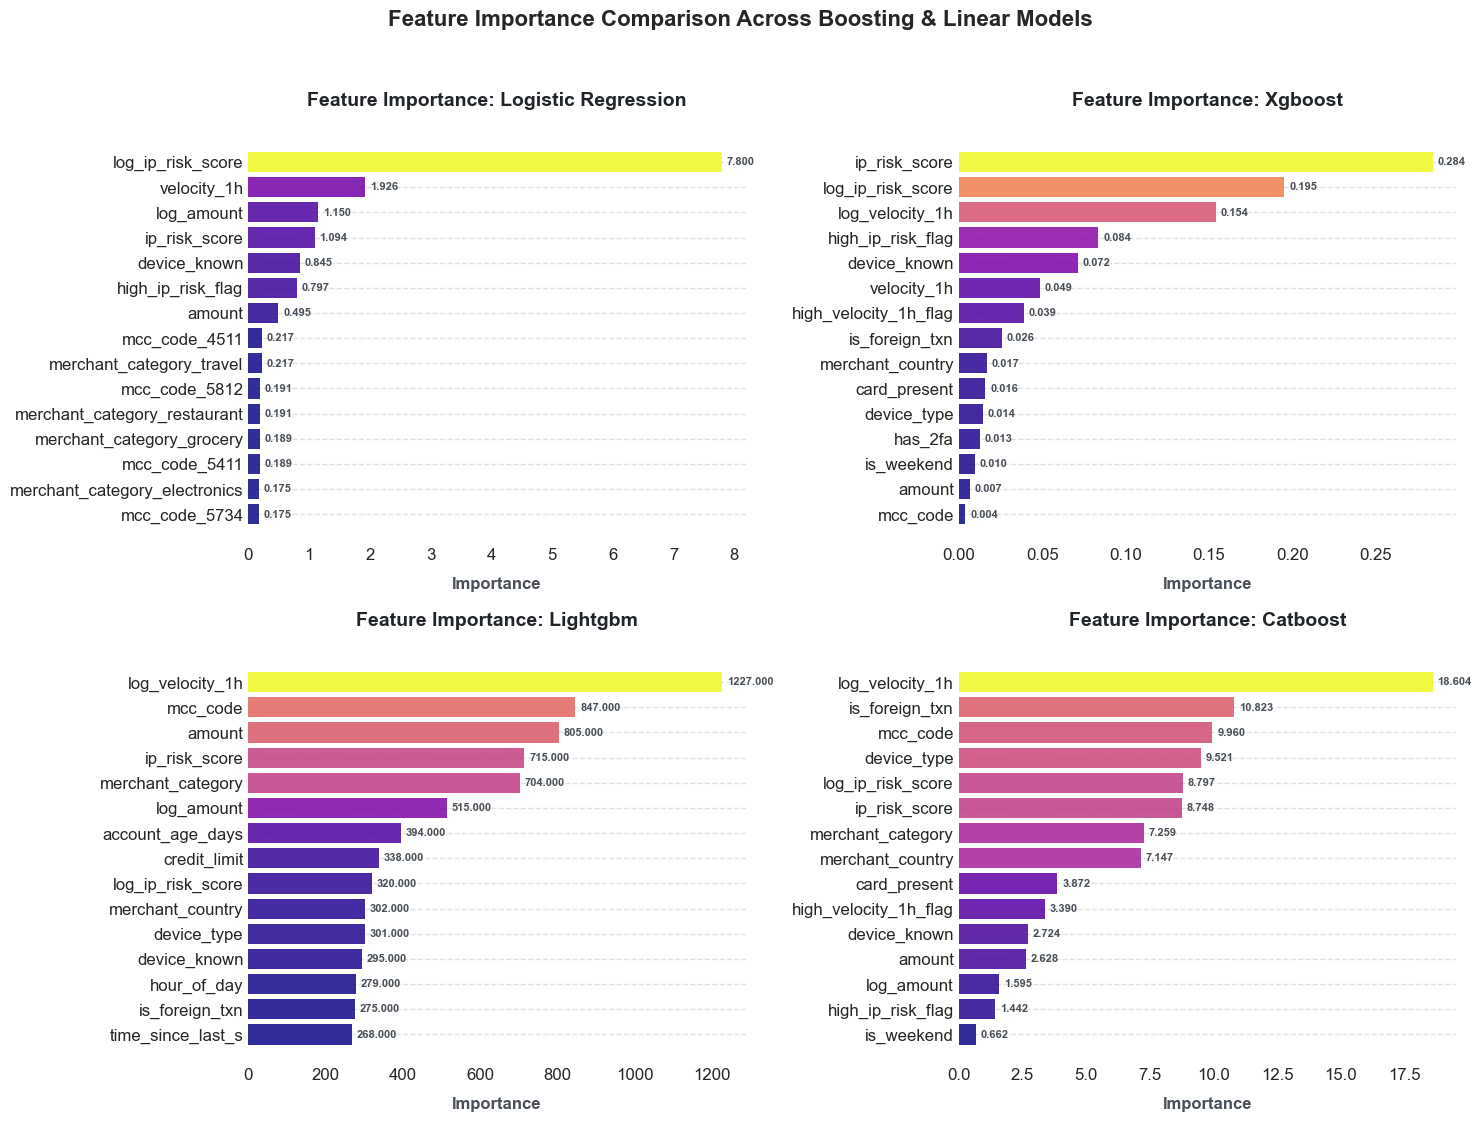

In [14]:
def plot_all_feature_importance(model_results, top_n=15, ncols=2):
    feature_models = [
        r for r in model_results
        if r.get("feature_importance_df") is not None and not r["feature_importance_df"].empty
    ]

    if not feature_models:
        print("Không có model nào có feature importance để vẽ.")
        return

    n_models = len(feature_models)
    nrows = ceil(n_models / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 5.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, result in zip(axes, feature_models):
        plot_df = (
            result["feature_importance_df"]
            .head(top_n)
            .sort_values("importance", ascending=True)
        )

        norm = plt.Normalize(plot_df['importance'].min(), plot_df['importance'].max())
        colors = plt.cm.plasma(norm(plot_df['importance']))

        bars = ax.barh(plot_df["feature"], plot_df["importance"], color=colors, edgecolor='none', alpha=0.85, zorder=3)
        for bar in bars:
            w = bar.get_width()
            ax.text(w + plot_df['importance'].max()*0.01, bar.get_y() + bar.get_height()/2,
                    f'{w:.3f}', va='center', fontsize=8, fontweight='600', color=COLORS['text_mid'])

        style_axis(ax, title=f"Feature Importance: {result['display_name']}", xlabel="Importance")

    for ax in axes[len(feature_models):]:
        ax.axis("off")

    fig.suptitle("Feature Importance Comparison Across Boosting & Linear Models", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_feature_importance(model_results, top_n=15, ncols=2)


> **Nhận xét biểu đồ Feature Importance**:
> - Có sự tương đồng cao về các features quan trọng giữa các tree-based models: `log_ip_risk_score`, `log_velocity_1h`, và `log_amount` luôn dẫn đầu.
> - Mô hình **LightGBM** phân bổ tầm quan trọng dàn trải và sâu hơn cho các features liên tục, ví dụ như `time_since_last_s` và `account_age_days`, giúp cải thiện độ mịn khi học các split ranh giới.
> - **XGBoost** nhấn mạnh đặc biệt vào các cờ phân loại rủi ro nhị phân (flags).
> - **Logistic Regression** (sử dụng hệ số tuyệt đối làm importance proxy) phụ thuộc rất mạnh vào một số ít features tuyến tính mạnh, làm hạn chế khả năng tương tác phi tuyến phức tạp.


# **H. Lựa chọn Mô hình Baseline Tốt nhất**

In [15]:
best_row = leaderboard.iloc[0]
best_model_name = best_row["model_name"]

best_result = next(r for r in model_results if r["model_name"] == best_model_name)

print("Best model selected:", best_result["display_name"])
print("Dataset branch     :", best_result["dataset"])
print("Use SMOTE          :", best_result["use_smote"])

pd.DataFrame(
    [
        {
            "accuracy": best_result["accuracy"],
            "precision": best_result["precision"],
            "recall": best_result["recall"],
            "f1_score": best_result["f1_score"],
            "roc_auc": best_result["roc_auc"],
            "pr_auc": best_result["pr_auc"],
        }
    ]
)


Best model selected: Lightgbm
Dataset branch     : tree
Use SMOTE          : True


,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,0.99294,0.806383,0.783598,0.794827,0.99485,0.87421


> **Nhận xét**: 
> - Mô hình được chọn làm baseline tốt nhất là **LightGBM** nhờ đạt chỉ số **PR-AUC tối ưu nhất** trong leaderboard.
> - Sự kết hợp giữa tốc độ huấn luyện cực nhanh, bộ nhớ tối ưu, khả năng xử lý biến phân loại trực tiếp qua label encoding giúp LightGBM trở thành ứng viên lý tưởng cho giai đoạn Hyperparameter Tuning và triển khai thực tế.


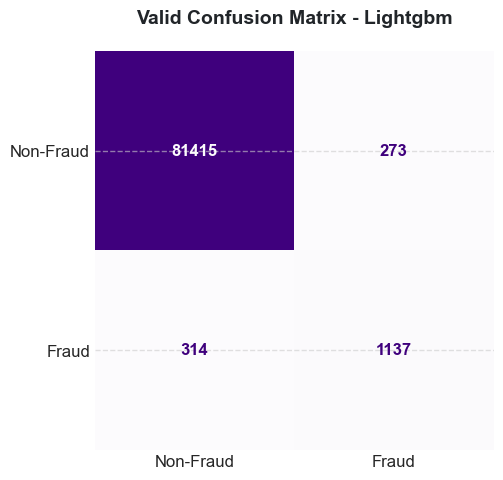

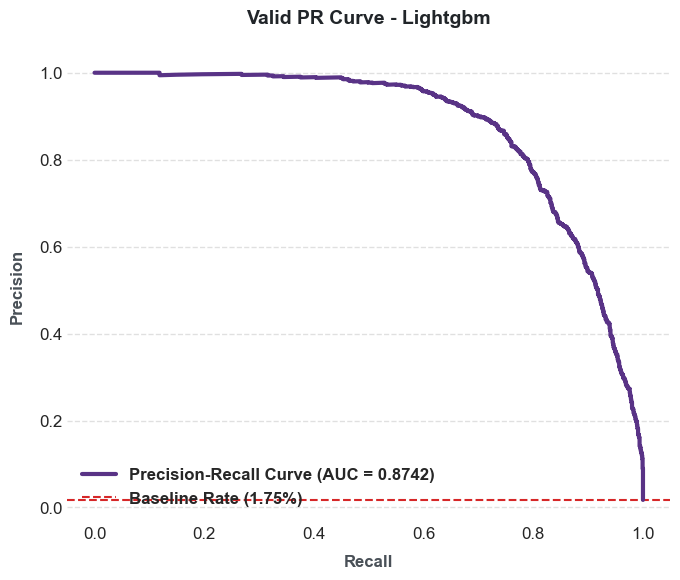

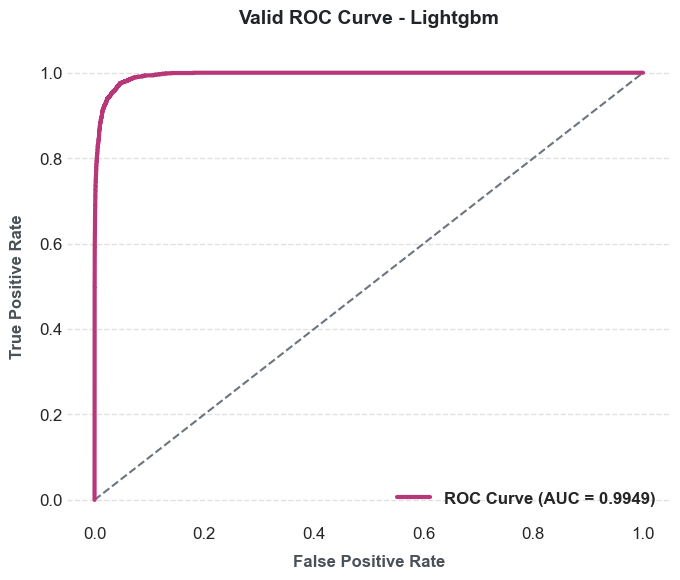

In [16]:
plot_confusion_matrix(
    y_true=best_result["y_valid_true"],
    y_pred=best_result["y_valid_pred"],
    title=f"Valid Confusion Matrix - {best_result['display_name']}",
)

plot_pr_curve(
    y_true=best_result["y_valid_true"],
    y_score=best_result["y_valid_score"],
    title=f"Valid PR Curve - {best_result['display_name']}",
)

plot_roc_curve(
    y_true=best_result["y_valid_true"],
    y_score=best_result["y_valid_score"],
    title=f"Valid ROC Curve - {best_result['display_name']}",
)


,feature,importance
0,log_velocity_1h,1227
1,mcc_code,847
2,amount,805
3,ip_risk_score,715
4,merchant_category,704
5,log_amount,515
6,account_age_days,394
7,credit_limit,338
8,log_ip_risk_score,320
9,merchant_country,302


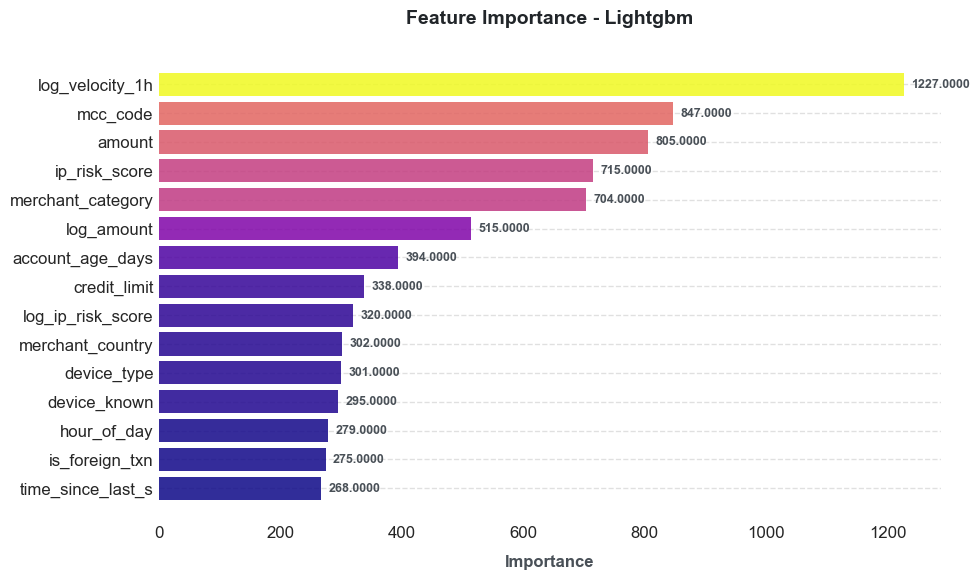

In [17]:
if best_result["feature_importance_df"] is not None:
    display(best_result["feature_importance_df"].head(20))
    plot_feature_importance(
        best_result["feature_importance_df"],
        title=f"Feature Importance - {best_result['display_name']}",
        top_n=15,
    )
else:
    print("This model does not expose feature importance.")


# **I. Kết luận và Hướng đi tiếp theo**

---

##  Các kết luận chính:
1. **LightGBM** là mô hình baseline tối ưu nhất dựa trên tiêu chí **PR-AUC**.
2. Phân tích confusion matrix cho thấy mặc dù tree-based models có Recall thấp hơn Logistic Regression một chút, nhưng tỷ lệ Precision cao hơn gấp nhiều lần, giúp hạn chế false positives (False Alarm) xuống mức tối thiểu.
3. Các features được tạo ra ở bước Feature Engineering (`log_ip_risk_score`, `log_velocity_1h`, `utilization`) đóng vai trò quan trọng trong việc tăng accuracy dự đoán.

##  Hướng phát triển tiếp theo:
- **Hyperparameter Tuning**: Thực hiện tuning các tham số quan trọng của LightGBM (như `num_leaves`, `max_depth`, `learning_rate`, `scale_pos_weight`) để tiếp tục đẩy cao PR-AUC.
- **Threshold Tuning**: Xác định probability threshold tối ưu dựa trên phân tích chi phí vận hành thương mại (Cost-Sensitive Matrix) để cân bằng giữa chi phí mất mát do lọt lưới fraud và chi phí xử lý cảnh báo giả.
